### *Small implemantation of the code (remember to read the Readme.txt):*

In the next cell I show how to make photometry using the class *PhotometryTool* defined in the file Photometry_Tool.py (for more information about the class itself you can look in the file Photometry_Tool.py where I hope that the future me will present an exhaustive clarification of the way the class works).

I use the *read_csv* funtion of **pandas** to read the Radial and Declination coordinates of the stars of interest, from the file "Ra_Dec_comp_stars.txt" that the past me created searching on aavso catalogue to find possible comparison stars for "our" V0536 Peg. If you don't trust me you can look by yourself: https://apps.aavso.org/vsp/photometry/?star=V0536+Peg&fov=60&maglimit=14.5&resolution=150&north=up&east=left

The aperture photometry is then implemented by initializing the class *PhotometryTool* with the path of the fits file to open, the star aperture, the gap anulus and the sky anulus (all in pixel). Then, using the attribute analyze, we can obtain a pandas DataFrame containing all the interest information the future me will provide.
This task is a work in progress, more information in the DataFrame will come soon, so stay tuned ;).

Then I just display the dataframe

In [1]:
import pandas as pd
from Photometry_Tool import PhotometryTool

tool = PhotometryTool(path = 'data/2024-11-15_18-15-32_G_-20.00_80.00s_0000_cal.fits',
                      r_star = 6, 
                      r_gap = 14, 
                      r_sky = 17)

positions = pd.read_csv('data/Ra_Deg_comp_stars.txt', names = ['Ra', 'Dec'])

results = tool.analyze(positions)

display(results)

/home/gigi/miniconda3/envs/astro/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Ra,Dec,Ra Centroid,Dec Centroid,star_aperture_sum,star_aperture_sum,instrumental_magnitude,sigma instrumental magnitude,AVG Julian Date
0,339.975790,13.437280,339.975765,13.437262,160094.335627,264349.447458,-11.620994,0.008395,2.460630e+06
1,339.980072,13.320056,339.980042,13.320097,207707.431125,264367.816707,-12.273077,0.005124,2.460630e+06
2,340.052917,13.471806,340.052928,13.471861,184007.675391,263795.259315,-12.000864,0.006259,2.460630e+06
3,339.790375,13.319195,339.790429,13.319188,175277.705827,262983.264043,-11.880548,0.006854,2.460630e+06
4,340.042542,13.533667,340.042515,13.533575,154395.708285,264656.338023,-11.504407,0.009214,2.460630e+06
5,339.998505,13.593278,339.998451,13.593275,134652.805510,264296.663108,-10.993109,0.013981,2.460630e+06
6,340.193542,13.436806,340.193495,13.436861,129468.514447,263627.167563,-10.810577,0.016289,2.460630e+06
7,339.899048,13.371472,339.898982,13.371466,120128.108204,262941.126303,-10.379643,0.023536,2.460630e+06


Now that it works for a single image, it could be useful to see how to implement it for a directory of fits image.

In the next cell I use the function Get_files_names from the file utilities.py to read the file names in the data directory and separate the fits file taken with the Blue filter from the ones taken using the Green filter, and I save the names in two separate list, so that it is easy to open the single files iterating through the list.

Then I use the function Load_dataset also from utilities.py to literaly load the datasets (did you expect that) in the form lists of pandas DataFrame. One can also chose to load the green dataset or the blue dataset only by changing the flag green (or blue) to False (you have to adapt the variable of the output obviouvsly).

By the way look how cool is the module *tqdm*. You can look at it here: https://pypi.org/project/tqdm/ . Isn't the coolest thing you ever seen?

In [2]:
from utilities import Get_files_names, Load_dataset

files_green_filter, files_blue_filter = Get_files_names()
green_dataset, blue_dataset = Load_dataset(files_green_filter, files_blue_filter, 
                                           green = True, blue = True)

Green Filter Loading:


100%|██████████| 50/50 [05:36<00:00,  6.73s/it]


Blue Filter Loading:


100%|██████████| 48/48 [05:30<00:00,  6.88s/it]


In the next cell I use the function *Plot_All_Stars* from visualization.py to plot all the stars of the dataset I load in the previous cell. I do it for the green filter data, but you can check also the blue filter one just changing the input of the function.

Hi, its me from the future, I've wrote this function just for debugging but then I noticed that it could be useful to keep it here just to show a simple visualization of the dataset.

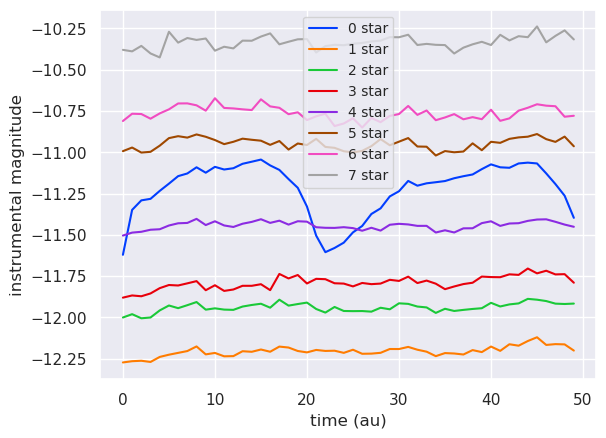

In [3]:
from visualization import Plot_All_Stars

Plot_All_Stars(green_dataset)

In the next cell I use the function *Plot_Diff_Phot* from visualization.py to plot the variable star (in our case V0539 Peg) and the difference between the comparison and the check stars. This is basically a more exhaustive version of the previous one, with all the information needed to do differential photometry. One can change the input of the function to obtained different plot. The proof is left to the reader (I've always wanted to say it :)).

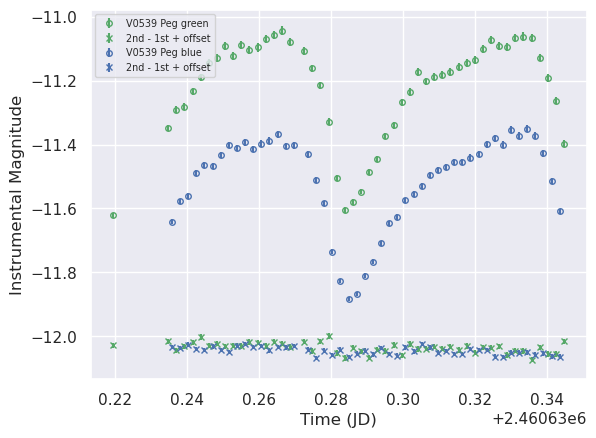

In [4]:
from visualization import Plot_Diff_Phot

Plot_Diff_Phot(dataset_green = green_dataset, dataset_blue = blue_dataset, 
               offset = -12.3, green_plot = True, blue_plot = True)

More to come.... stay tuned.